In [1]:
from google.colab import files


In [2]:
uploaded=files.upload()

Saving northwind.db to northwind.db


In [3]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
conn = sqlite3.connect("northwind.db")

In [5]:
pd.read_sql("""
SELECT name
FROM sqlite_master
WHERE type='table';
""", conn)

,name
0,Categories
1,sqlite_sequence
2,CustomerCustomerDemo
3,CustomerDemographics
4,Customers
5,Employees
6,EmployeeTerritories
7,Order Details
8,Orders
9,Products


In [12]:
top_products=pd.read_sql("""SELECT
    p.ProductName,
    SUM(od.Quantity) AS TotalSold
FROM "Order Details" od
JOIN Products p
ON od.ProductID = p.ProductID
GROUP BY p.ProductName
ORDER BY TotalSold DESC
LIMIT 10;""",conn)
top_products

,ProductName,TotalSold
0,Louisiana Hot Spiced Okra,206213
1,Sir Rodney's Marmalade,205637
2,Teatime Chocolate Biscuits,205487
3,Sirop d'érable,205005
4,Gumbär Gummibärchen,204761
5,Outback Lager,204403
6,Ravioli Angelo,204251
7,Raclette Courdavault,204137
8,Uncle Bob's Organic Dried Pears,203970
9,Sasquatch Ale,203667


In [13]:
customers=pd.read_sql("""SELECT
    c.CompanyName,
    ROUND(SUM(od.UnitPrice*od.Quantity*(1-od.Discount)),2) AS Revenue
FROM Customers c
JOIN Orders o
ON c.CustomerID=o.CustomerID
JOIN "Order Details" od
ON o.OrderID=od.OrderID
GROUP BY c.CompanyName
ORDER BY Revenue DESC
LIMIT 10;""",conn)
customers

,CompanyName,Revenue
0,IT,9745371.29
1,B's Beverages,6154115.34
2,Hungry Coyote Import Store,5698023.67
3,Rancho grande,5559110.08
4,Gourmet Lanchonetes,5552309.81
5,Ana Trujillo Emparedados y helados,5534356.65
6,Ricardo Adocicados,5524517.31
7,Folies gourmandes,5505502.85
8,Let's Stop N Shop,5462198.02
9,LILA-Supermercado,5437438.34


In [14]:
monthly_sales=pd.read_sql("""SELECT
strftime('%Y-%m',OrderDate) AS Month,
ROUND(SUM(UnitPrice*Quantity*(1-Discount)),2) AS Sales
FROM Orders o
JOIN "Order Details" od
ON o.OrderID=od.OrderID
GROUP BY Month
ORDER BY Month;""",conn)
monthly_sales

,Month,Sales
0,2012-07,2066219.40
1,2012-08,3556875.79
2,2012-09,3440144.98
3,2012-10,3201529.96
4,2012-11,2980494.74
...,...,...
131,2023-06,3071787.73
132,2023-07,3350337.36
133,2023-08,3293158.67
134,2023-09,3544698.51


In [15]:
category=pd.read_sql("""SELECT
c.CategoryName,
ROUND(SUM(od.UnitPrice*od.Quantity*(1-od.Discount)),2) AS Revenue
FROM Categories c
JOIN Products p
ON c.CategoryID=p.CategoryID
JOIN "Order Details" od
ON p.ProductID=od.ProductID
GROUP BY c.CategoryName
ORDER BY Revenue DESC;""",conn)
category

,CategoryName,Revenue
0,Beverages,92163184.18
1,Confections,66337803.07
2,Meat/Poultry,64881147.97
3,Dairy Products,58018116.79
4,Condiments,55795126.78
5,Seafood,49921604.17
6,Produce,32701119.88
7,Grains/Cereals,28568530.34


In [16]:
purchase=pd.read_sql("""SELECT
CustomerID,
COUNT(OrderID) AS TotalOrders
FROM Orders
GROUP BY CustomerID
ORDER BY TotalOrders DESC;""",conn)
purchase

,CustomerID,TotalOrders
0,BSBEV,210
1,RICAR,203
2,LILAS,203
3,GOURL,202
4,PRINI,200
...,...,...
88,AROUT,156
89,LACOR,155
90,FURIB,155
91,FISSA,155


In [17]:
top_products.describe()

,TotalSold
count,10.000000
mean,204753.100000
std,820.692452
min,203667.000000
25%,204165.500000
50%,204582.000000
75%,205366.500000
max,206213.000000


In [18]:
customers.describe()

,Revenue
count,1.000000e+01
mean,6.017294e+06
std,1.326135e+06
min,5.437438e+06
25%,5.510256e+06
50%,5.543333e+06
75%,5.663295e+06
max,9.745371e+06


In [19]:
monthly_sales.describe()

,Sales
count,1.360000e+02
mean,3.296961e+06
std,3.885097e+05
min,2.066219e+06
25%,3.050957e+06
50%,3.285466e+06
75%,3.518739e+06
max,4.377795e+06


In [20]:
category.describe()

,Revenue
count,8.000000e+00
mean,5.604833e+07
std,2.010646e+07
min,2.856853e+07
25%,4.561648e+07
50%,5.690662e+07
75%,6.524531e+07
max,9.216318e+07


In [21]:
purchase.describe()

,TotalOrders
count,93.000000
mean,175.075269
std,12.737514
min,154.000000
25%,165.000000
50%,175.000000
75%,183.000000
max,210.000000


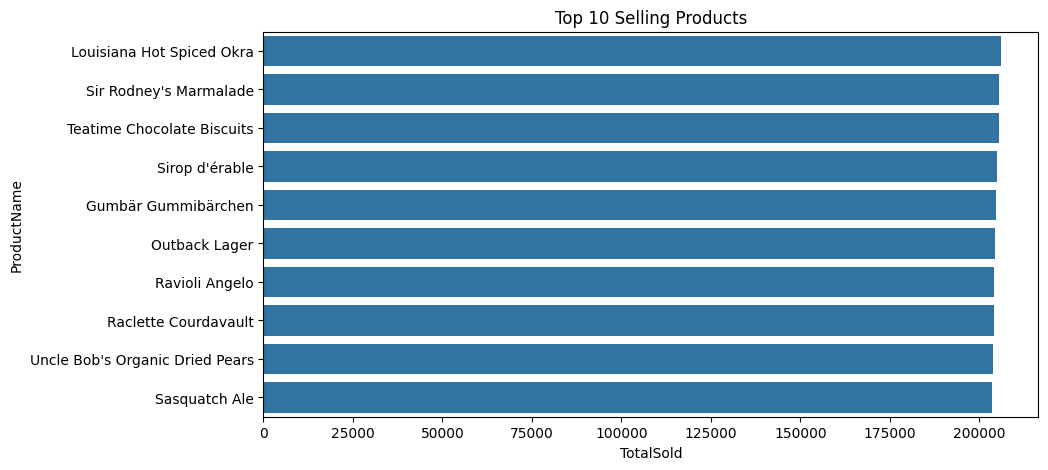

In [22]:
plt.figure(figsize=(10,5))
sns.barplot(data=top_products,
            x="TotalSold",
            y="ProductName")
plt.title("Top 10 Selling Products")
plt.show()

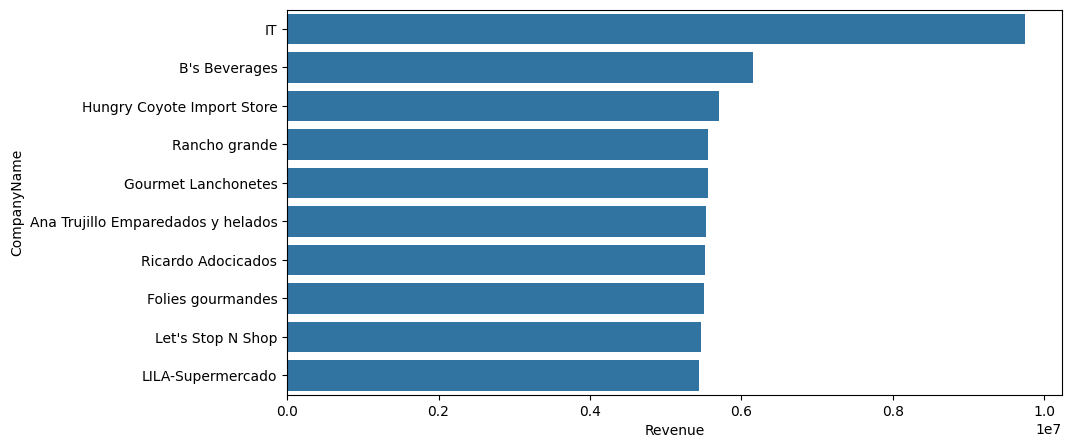

In [23]:
plt.figure(figsize=(10,5))
sns.barplot(data=customers,
            x="Revenue",
            y="CompanyName")
plt.show()

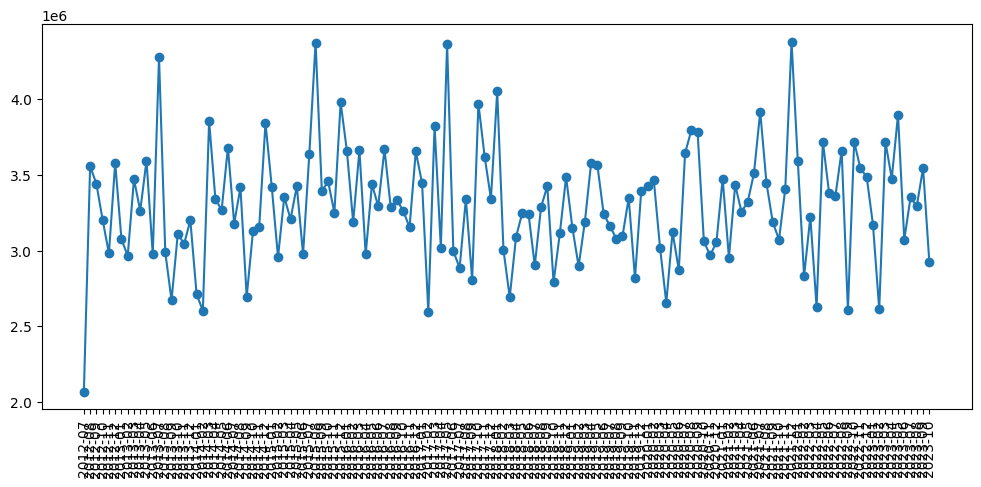

In [24]:
plt.figure(figsize=(12,5))
plt.plot(monthly_sales["Month"],
         monthly_sales["Sales"],
         marker='o')
plt.xticks(rotation=90)
plt.show()

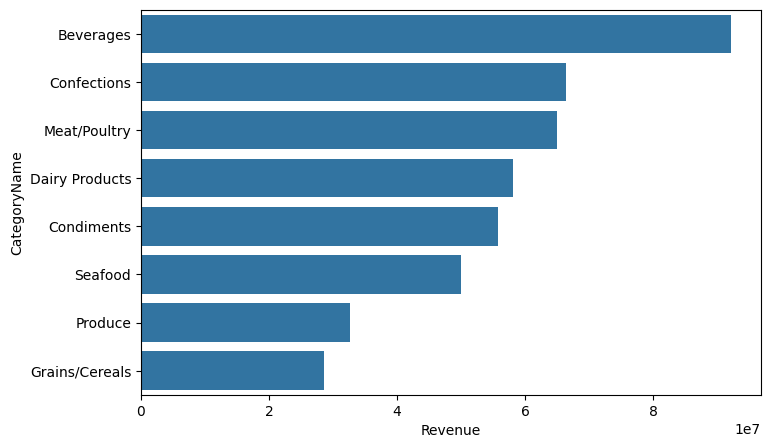

In [26]:
plt.figure(figsize=(8,5))
sns.barplot(data=category,
            x="Revenue",
            y="CategoryName")
plt.show()